In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
da = pd.read_csv("bank-additional-full.csv", sep=";")


In [3]:
da.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
da.shape


(41188, 21)

In [5]:
da.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [6]:
da.describe()


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [7]:
da.isnull().sum()


age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [8]:
da.duplicated().sum()


np.int64(12)

In [9]:
da["y"].value_counts()


y
no     36548
yes     4640
Name: count, dtype: int64

In [10]:
print((da["y"] == "yes").mean())
print((da["y"] == "no").mean())


0.11265417111780131
0.8873458288821987


In [11]:
num_cols = ["age", "duration", "campaign", "pdays", "previous", "emp.var.rate", "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]
cat_cols = ["job", "marital", "education", "default", "housing", "loan", "contact", "month", "day_of_week", "poutcome"]
print(num_cols)
print(cat_cols)


['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [12]:
da[num_cols].nunique()


age                 78
duration          1544
campaign            42
pdays               27
previous             8
emp.var.rate        10
cons.price.idx      26
cons.conf.idx       26
euribor3m          316
nr.employed         11
dtype: int64

In [13]:
da[cat_cols].nunique()


job            12
marital         4
education       8
default         3
housing         3
loan            3
contact         2
month          10
day_of_week     5
poutcome        3
dtype: int64

In [14]:
def unknown_rate(name):
    return (da[name].astype(str) == "unknown").mean()


In [15]:
for c in cat_cols:
    print(c, unknown_rate(c))


job 0.008012042342429833
marital 0.0019423132951345051
education 0.042026803923472855
default 0.20872584247839177
housing 0.0240361270272895
loan 0.0240361270272895
contact 0.0
month 0.0
day_of_week 0.0
poutcome 0.0


In [16]:
print((da["pdays"] == 999).mean())
print((da["previous"] == 0).mean())
da["poutcome"].value_counts()


0.9632174419733903
0.8634310964358551


poutcome
nonexistent    35563
failure         4252
success         1373
Name: count, dtype: int64

In [17]:
def show_yes(name):
    out = da.groupby(name)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
    print(out)


In [18]:
def show_yes_bar(name):
    out = da.groupby(name)["y"].apply(lambda s: (s == "yes").mean()).sort_values(ascending=False)
    sns.barplot(x=out.values, y=out.index)
    plt.show()


In [19]:
def box_by_y(name):
    sns.boxplot(x="y", y=name, data=da)
    plt.show()


In [20]:
def hist_num(name):
    sns.histplot(da[name], bins=30)
    plt.show()


In [21]:
def mean_by_y(name):
    print(da.groupby("y")[name].mean())


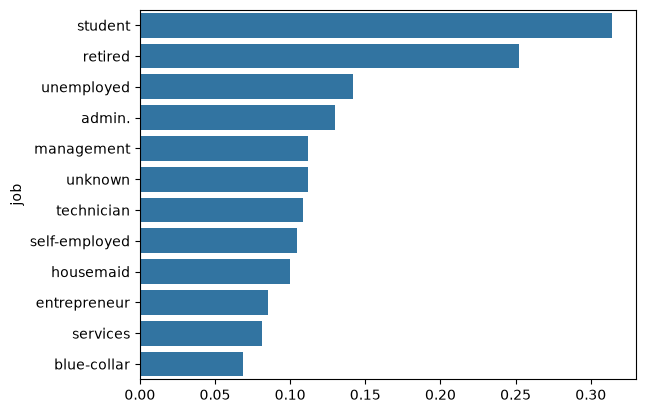

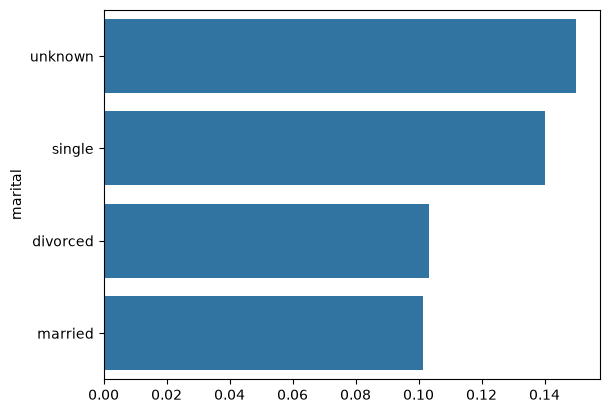

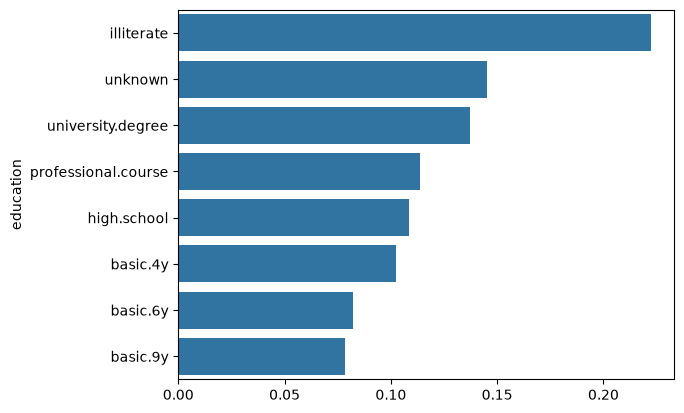

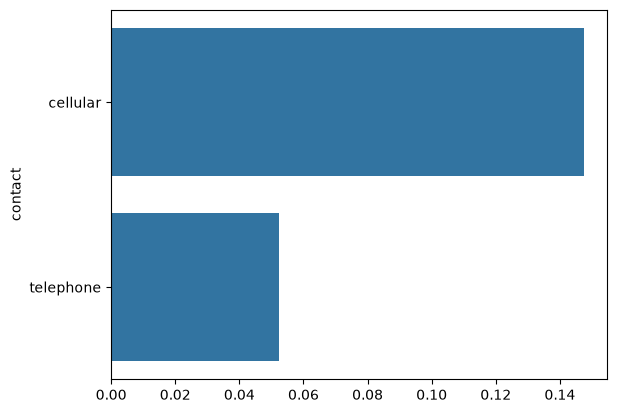

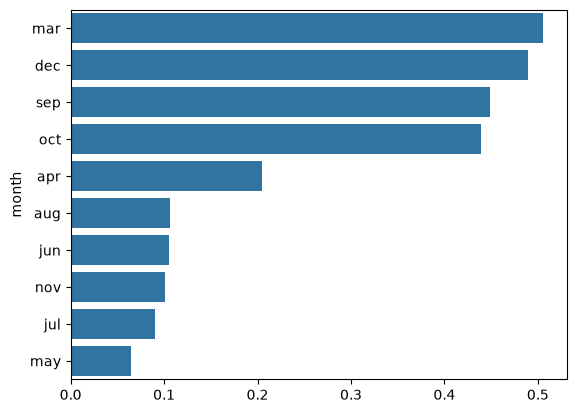

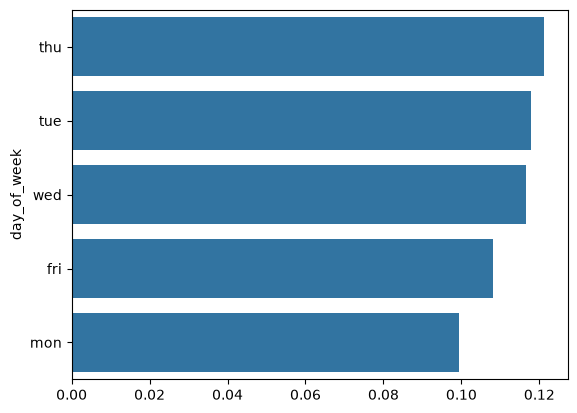

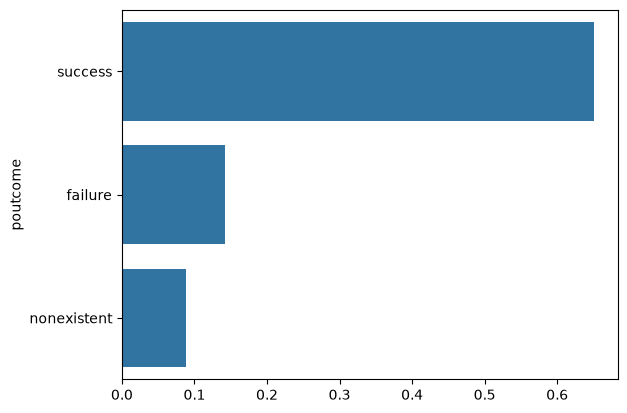

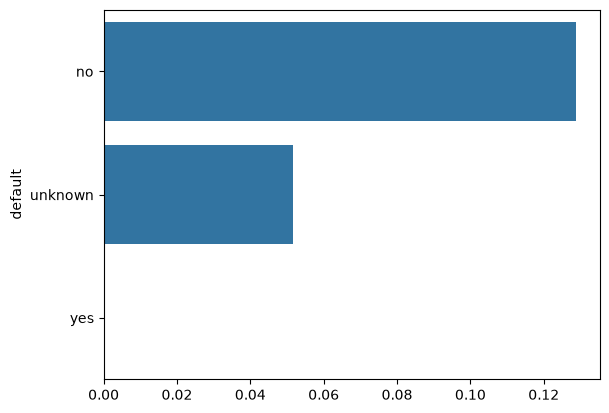

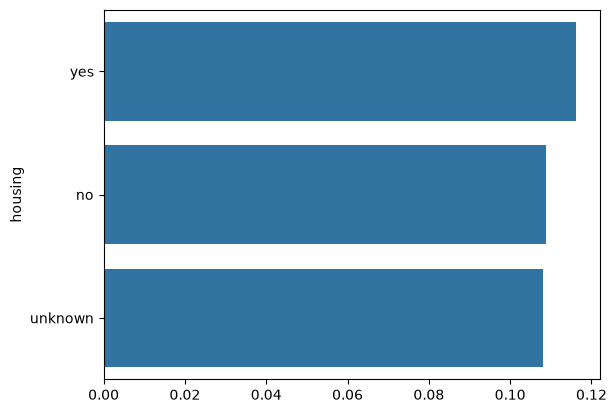

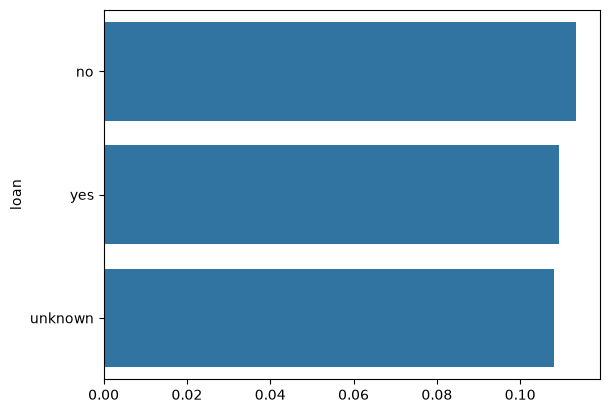

In [22]:
for c in ["job", "marital", "education", "contact", "month", "day_of_week", "poutcome", "default", "housing", "loan"]:
    show_yes_bar(c)


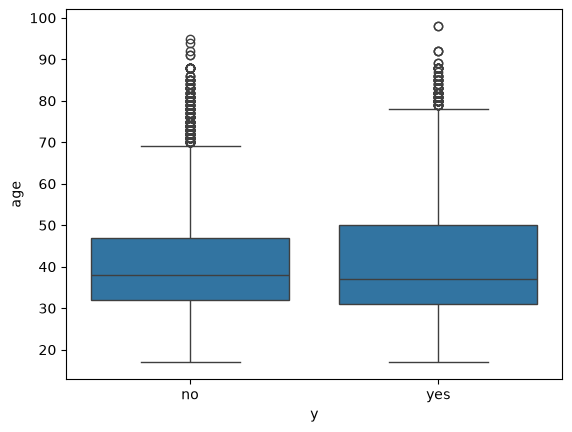

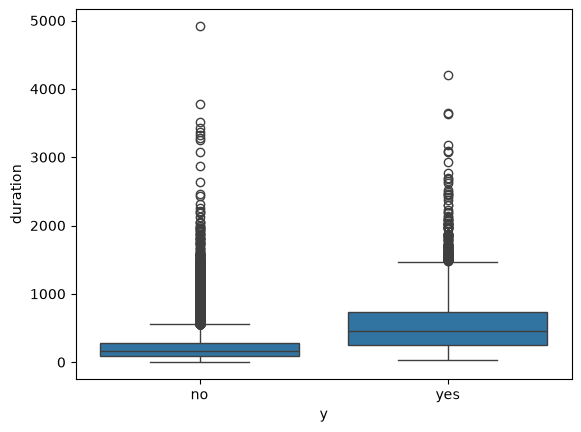

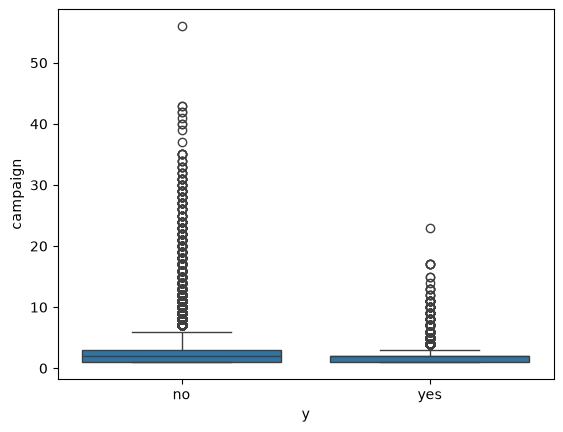

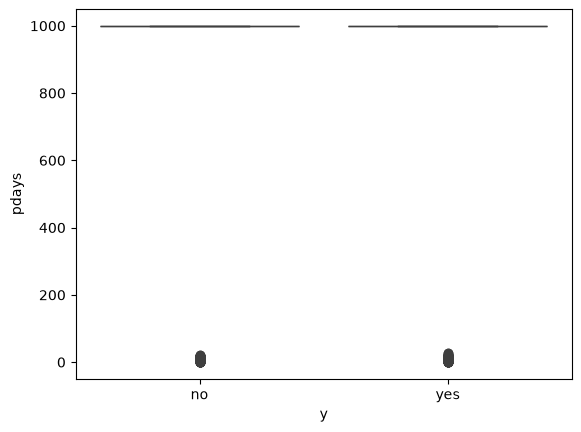

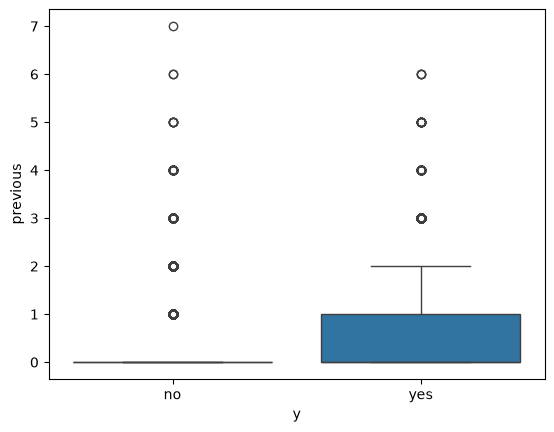

In [23]:
for c in ["age", "duration", "campaign", "pdays", "previous"]:
    box_by_y(c)


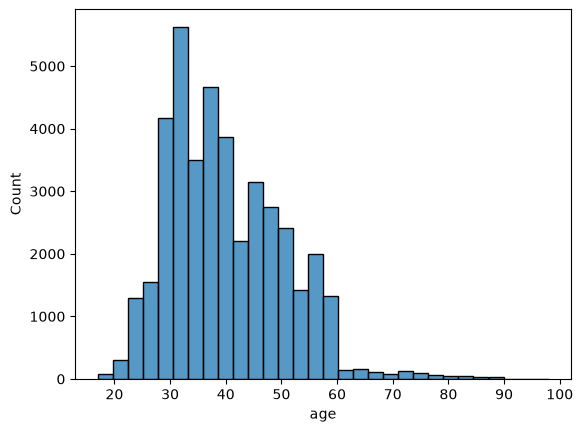

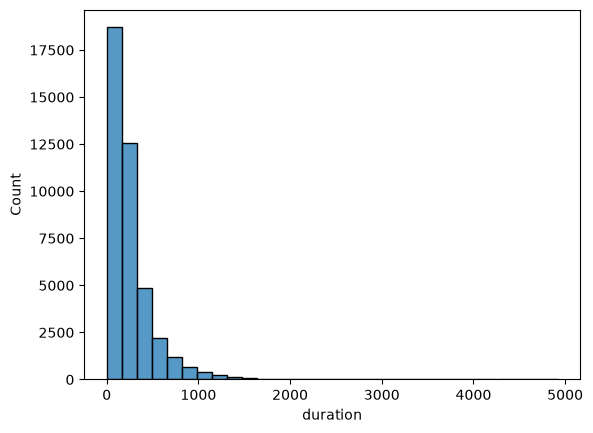

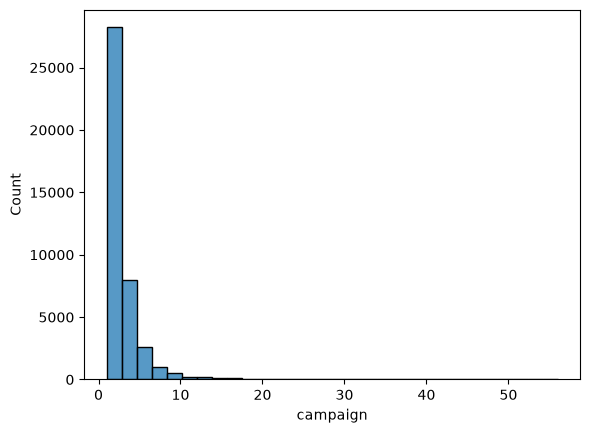

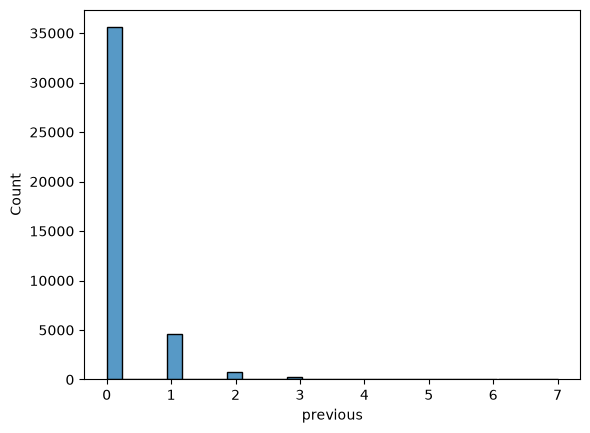

In [24]:
for c in ["age", "duration", "campaign", "previous"]:
    hist_num(c)


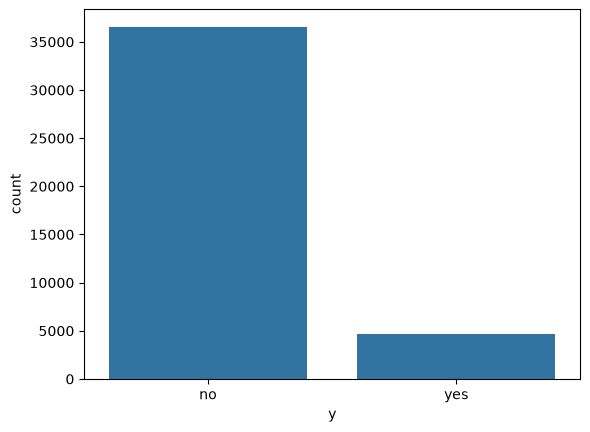

In [25]:
sns.countplot(x="y", data=da)
plt.show()


In [26]:
for c in num_cols:
    mean_by_y(c)


y
no     39.911185
yes    40.913147
Name: age, dtype: float64
y
no     220.844807
yes    553.191164
Name: duration, dtype: float64
y
no     2.633085
yes    2.051724
Name: campaign, dtype: float64
y
no     984.113878
yes    792.035560
Name: pdays, dtype: float64
y
no     0.132374
yes    0.492672
Name: previous, dtype: float64
y
no     0.248875
yes   -1.233448
Name: emp.var.rate, dtype: float64
y
no     93.603757
yes    93.354386
Name: cons.price.idx, dtype: float64
y
no    -40.593097
yes   -39.789784
Name: cons.conf.idx, dtype: float64
y
no     3.811491
yes    2.123135
Name: euribor3m, dtype: float64
y
no     5176.166600
yes    5095.115991
Name: nr.employed, dtype: float64


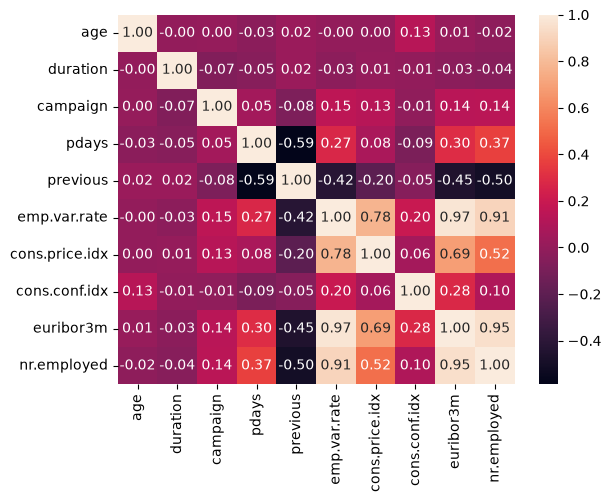

In [27]:
sns.heatmap(da[num_cols].corr(), annot=True, fmt=".2f")
plt.show()


In [28]:
def before_call(name):
    if name == "duration":
        return "no"
    return "yes"


In [29]:
for c in da.columns:
    print(c, before_call(c))


age yes
job yes
marital yes
education yes
default yes
housing yes
loan yes
contact yes
month yes
day_of_week yes
duration no
campaign yes
pdays yes
previous yes
poutcome yes
emp.var.rate yes
cons.price.idx yes
cons.conf.idx yes
euribor3m yes
nr.employed yes
y yes


In [30]:
print("rows", len(da))
print("cols", len(da.columns))
print("yes rate", (da["y"] == "yes").mean())
print("pdays 999 rate", (da["pdays"] == 999).mean())
print("default unknown", unknown_rate("default"))
print("education unknown", unknown_rate("education"))
print("job unknown", unknown_rate("job"))


rows 41188
cols 21
yes rate 0.11265417111780131
pdays 999 rate 0.9632174419733903
default unknown 0.20872584247839177
education unknown 0.042026803923472855
job unknown 0.008012042342429833


rows 41188
cols 21
yes rate 0.11265417111780131
pdays 999 rate 0.9632174419733903
default unknown 0.20872584247839177
education unknown 0.042026803923472855
job unknown 0.008012042342429833
duration is not available before the call
